# 🎯 World Model — CartPole-v1

Entraîne 3 configurations :
- **Config 1** : Standard — S(t+1) direct
- **Config 2** : MultiStep — S(t+5) direct  
- **Config 3** : Delta — ΔS = S(t+1) - St

- Early stopping |  Checkpoints |  Évaluation test

## 1. Imports & Setup

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime


ENV_NAME = "CartPole-v1"
DATA_PATH = "../data/collected/CartPole"
CHECKPOINT_DIR = "world_model/checkpoints_CartPole"
PLOT_DIR = "world_model/plots"

EPOCHS = 200
BATCH_SIZE = 256
LR = 1e-3
HIDDEN = 64
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"✅ Setup OK")
print(f"  Device: {DEVICE}")
print(f"  Data: {DATA_PATH}")
print(f"  Checkpoints: {CHECKPOINT_DIR}")

✅ Setup OK
  Device: cpu
  Data: ../data/collected/CartPole
  Checkpoints: world_model/checkpoints_CartPole


## 2. Charger les données

In [ ]:
def load_data():
    trans_path = os.path.join(DATA_PATH, "transitions.npz")
    trans = np.load(trans_path, allow_pickle=True)
    
    scaler_path = os.path.join(DATA_PATH, "scaler.npz")
    scaler = np.load(scaler_path, allow_pickle=True)
    
    return trans, scaler


trans, scaler = load_data()

S_tr_n = trans["states_train"].astype(np.float32)
A_tr = trans["actions_train"].astype(np.int32)
A_tr_oh = trans["actions_onehot_train"].astype(np.float32)
NS_tr_n = trans["next_states_train"].astype(np.float32)

S_va_n = trans["states_val"].astype(np.float32)
A_va = trans["actions_val"].astype(np.int32)
A_va_oh = trans["actions_onehot_val"].astype(np.float32)
NS_va_n = trans["next_states_val"].astype(np.float32)

S_te_n = trans["states_test"].astype(np.float32)
A_te = trans["actions_test"].astype(np.int32)
A_te_oh = trans["actions_onehot_test"].astype(np.float32)
NS_te_n = trans["next_states_test"].astype(np.float32)

state_mean = scaler["state_mean"].astype(np.float32)
state_std = scaler["state_std"].astype(np.float32)
delta_mean = scaler["delta_mean"].astype(np.float32)
delta_std = scaler["delta_std"].astype(np.float32)

STATE_DIM = S_tr_n.shape[1]
ACTION_DIM = A_tr_oh.shape[1]
N_STEPS = 5

print(f"\nDonnées chargées")
print(f"  STATE_DIM: {STATE_DIM}")
print(f"  ACTION_DIM: {ACTION_DIM}")
print(f"  Train: {len(S_tr_n):,} | Val: {len(S_va_n):,} | Test: {len(S_te_n):,}")
print(f"  Normalization: state_mean={np.round(state_mean, 4)}, state_std={np.round(state_std, 4)}")


📦 Données chargées
  STATE_DIM: 4
  ACTION_DIM: 2
  Train: 70,871 | Val: 9,522 | Test: 19,604
  Normalization: state_mean=[-0.0002 -0.0203  0.0041  0.0263], state_std=[0.4882 0.8093 0.1225 0.6656]


## 3. Architecture WorldModel

In [ ]:
class WorldModel(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int,
                 config: int = 3, n_step: int = 5,
                 hidden: int = HIDDEN):
        super().__init__()
        assert config in (1, 2, 3),

        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.config = config
        self.n_step = n_step if config == 2 else 1

        in_dim = obs_dim + (n_step * act_dim if config == 2 else act_dim)

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, obs_dim),
        )

    def forward(self, state: torch.Tensor,
                action_input: torch.Tensor) -> torch.Tensor:
        """
        state        : (batch, obs_dim)
        action_input : (batch, act_dim)              configs 1 & 3
                     | (batch, n_step * act_dim)     config  2
        retourne     : (batch, obs_dim)
        """
        return self.net(torch.cat([state, action_input], dim=-1))

    def predict(self, state: torch.Tensor,
                action_input: torch.Tensor) -> torch.Tensor:
        """Retourne toujours un état absolu (applique S+ΔS pour config 3)."""
        out = self.forward(state, action_input)
        return state + out if self.config == 3 else out


print("Architecture WorldModel définie")

✅ Architecture WorldModel définie


## 4. Early Stopping

In [ ]:
class EarlyStopping:    
    def __init__(self, patience: int = 8, min_delta: float = 1e-6):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.num_bad = 0

    def step(self, loss: float) -> bool:
        if loss < self.best - self.min_delta:
            self.best = loss
            self.num_bad = 0
            return False
        self.num_bad += 1
        return self.num_bad >= self.patience


print("EarlyStopping défini")

✅ EarlyStopping défini


## 5. Construction des datasets

In [ ]:
def build_dataset_config1_3(S_norm, A_oh, NS_norm, config: int):
    """
    Configs 1 & 3 : construire (X, Y) depuis transitions individuelles.
    
    Config 1 : X=[s_norm|a_oh]  Y=ns_norm
    Config 3 : X=[s_norm|a_oh]  Y=ns_norm - s_norm  (ΔS)
    """
    assert config in (1, 3), "Config 1 ou 3 uniquement"
    
    X = np.concatenate([S_norm, A_oh], axis=1).astype(np.float32)
    Y = NS_norm - S_norm if config == 3 else NS_norm
    Y = Y.astype(np.float32)
    
    return torch.FloatTensor(X).to(DEVICE), torch.FloatTensor(Y).to(DEVICE)


def build_dataset_config2(seq_data):
    """
    Config 2 : MultiStep — construire (X, Y) depuis sequences_n5.npz.
    
    X = [S0 | A0_oh | A1_oh | ... | An-1_oh]
    Y = S(t+n)
    """
    seq_path = os.path.join(DATA_PATH, "sequences_n5.npz")
    seq = np.load(seq_path, allow_pickle=True)
    
    S_n = seq["states_train"].astype(np.float32)   
    A_oh_n = seq["actions_onehot_train"].astype(np.float32) 
    SN_n = seq["states_n_train"].astype(np.float32)
    
    M = len(S_n)
    n_step = A_oh_n.shape[1]
    
    A_flat = A_oh_n.reshape(M, -1)  
    X = np.concatenate([S_n, A_flat], axis=1).astype(np.float32)
    Y = SN_n.astype(np.float32)
    
    print(f"  Config 2 (MultiStep, n={n_step}): X.shape={X.shape}, Y.shape={Y.shape}")
    return torch.FloatTensor(X).to(DEVICE), torch.FloatTensor(Y).to(DEVICE)


print(f"\n📊 Construction datasets...")
print(f"\n  Config 1 & 3 (Transitions individuelles):")
X_tr_c1, Y_tr_c1 = build_dataset_config1_3(S_tr_n, A_tr_oh, NS_tr_n, config=1)
X_va_c1, Y_va_c1 = build_dataset_config1_3(S_va_n, A_va_oh, NS_va_n, config=1)
X_te_c1, Y_te_c1 = build_dataset_config1_3(S_te_n, A_te_oh, NS_te_n, config=1)
print(f"    Train: {X_tr_c1.shape[0]:,} | Val: {X_va_c1.shape[0]:,} | Test: {X_te_c1.shape[0]:,}")

X_tr_c3, Y_tr_c3 = build_dataset_config1_3(S_tr_n, A_tr_oh, NS_tr_n, config=3)
X_va_c3, Y_va_c3 = build_dataset_config1_3(S_va_n, A_va_oh, NS_va_n, config=3)
X_te_c3, Y_te_c3 = build_dataset_config1_3(S_te_n, A_te_oh, NS_te_n, config=3)

print(f"\n  Config 2 (MultiStep sequences):")
X_tr_c2, Y_tr_c2 = build_dataset_config2(None)

seq_path = os.path.join(DATA_PATH, "sequences_n5.npz")
seq = np.load(seq_path, allow_pickle=True)
S_n_va = seq["states_val"].astype(np.float32)
A_oh_n_va = seq["actions_onehot_val"].astype(np.float32)
SN_n_va = seq["states_n_val"].astype(np.float32)
S_n_te = seq["states_test"].astype(np.float32)
A_oh_n_te = seq["actions_onehot_test"].astype(np.float32)
SN_n_te = seq["states_n_test"].astype(np.float32)

M_va = len(S_n_va)
n_step = A_oh_n_va.shape[1]
A_flat_va = A_oh_n_va.reshape(M_va, -1)
X_va_c2 = np.concatenate([S_n_va, A_flat_va], axis=1).astype(np.float32)
Y_va_c2 = SN_n_va.astype(np.float32)

M_te = len(S_n_te)
A_flat_te = A_oh_n_te.reshape(M_te, -1)
X_te_c2 = np.concatenate([S_n_te, A_flat_te], axis=1).astype(np.float32)
Y_te_c2 = SN_n_te.astype(np.float32)

X_va_c2 = torch.FloatTensor(X_va_c2).to(DEVICE)
Y_va_c2 = torch.FloatTensor(Y_va_c2).to(DEVICE)
X_te_c2 = torch.FloatTensor(X_te_c2).to(DEVICE)
Y_te_c2 = torch.FloatTensor(Y_te_c2).to(DEVICE)
print(f"    Train: {X_tr_c2.shape[0]:,} | Val: {X_va_c2.shape[0]:,} | Test: {X_te_c2.shape[0]:,}")

print(f"\n✅ Datasets construits")


📊 Construction datasets...

  Config 1 & 3 (Transitions individuelles):
    Train: 70,871 | Val: 9,522 | Test: 19,604

  Config 2 (MultiStep sequences):
  Config 2 (MultiStep, n=5): X.shape=(58346, 14), Y.shape=(58346, 4)
    Train: 58,346 | Val: 7,737 | Test: 16,019

✅ Datasets construits


## 6. Entraînement

In [ ]:
def train_world_model(config: int, X_tr, Y_tr, X_va, Y_va, X_te, Y_te):
    print(f"\n{'='*70}")
    print(f"  WorldModel | env={ENV_NAME} | config={config}")
    print(f"  device={DEVICE} | hidden={HIDDEN} | epochs={EPOCHS}")
    print(f"{'='*70}\n")

    train_loader = DataLoader(TensorDataset(X_tr, Y_tr),
                              batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_va, Y_va),
                            batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_te, Y_te),
                             batch_size=BATCH_SIZE, shuffle=False)

    n_step = 5 if config == 2 else 1
    model = WorldModel(STATE_DIM, ACTION_DIM, config, n_step, HIDDEN).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=LR)
    sched = optim.lr_scheduler.StepLR(opt, step_size=15, gamma=0.5)
    loss_fn = nn.MSELoss()
    stopper = EarlyStopping(patience=8)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"[WM] Paramètres : {n_params:,}\n")

    # Boucle d'entraînement
    best_val = float("inf")
    best_sd = None
    tr_losses, val_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            s_b = xb[:, :STATE_DIM]
            a_b = xb[:, STATE_DIM:]
            pred = model.forward(s_b, a_b)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader.dataset)
        tr_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                s_b = xb[:, :STATE_DIM]
                a_b = xb[:, STATE_DIM:]
                pred = model.forward(s_b, a_b)
                val_loss += loss_fn(pred, yb).item() * len(xb)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        sched.step()

        if val_loss < best_val:
            best_val = val_loss
            best_sd = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{EPOCHS} | "
                  f"train={train_loss:.6f} | "
                  f"val={val_loss:.6f} | "
                  f"best_val={best_val:.6f} | "
                  f"lr={sched.get_last_lr()[0]:.1e}")

        if stopper.step(val_loss):
            print(f"\n[WM] Early stopping à l'epoch {epoch} (best_val={best_val:.6f})")
            break

    model.load_state_dict(best_sd)
    model.eval()

    test_mse = 0.0
    test_mae = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            s_b = xb[:, :STATE_DIM]
            a_b = xb[:, STATE_DIM:]
            pred = model.forward(s_b, a_b)
            test_mse += loss_fn(pred, yb).item() * len(xb)
            test_mae += torch.mean(torch.abs(pred - yb)).item() * len(xb)
    
    test_mse /= len(test_loader.dataset)
    test_mae /= len(test_loader.dataset)
    print(f"\n[TEST] MSE={test_mse:.6f} | MAE={test_mae:.6f}")

    tag = f"config{config}" + (f"_n5" if config == 2 else "")
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"wm_{ENV_NAME}_{tag}.pt")
    torch.save({
        "state_dict": model.state_dict(),
        "config": config,
        "obs_dim": STATE_DIM,
        "act_dim": ACTION_DIM,
        "hidden": HIDDEN,
        "state_mean": state_mean,
        "state_std": state_std,
    }, ckpt_path)
    print(f"\n[SAVE] → {ckpt_path}")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(tr_losses, label="Train Loss", linewidth=2)
    ax.plot(val_losses, label="Val Loss", linewidth=2)
    ax.axhline(best_val, color="red", linestyle="--", label=f"Best Val: {best_val:.6f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Learning Curve — Config {config} ({ENV_NAME})")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    
    plot_path = os.path.join(PLOT_DIR, f"losses_config{config}.png")
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"[PLOT] → {plot_path}")

    return model, best_val, test_mse, test_mae


print("Fonction d'entraînement définie")

✅ Fonction d'entraînement définie


## 7. Entraîner Config 1 (Standard)


  WorldModel | env=CartPole-v1 | config=1
  device=cpu | hidden=64 | epochs=200

[WM] Paramètres : 9,028

  Epoch   1/200 | train=0.096358 | val=0.000962 | best_val=0.000962 | lr=1.0e-03
  Epoch   5/200 | train=0.000203 | val=0.000210 | best_val=0.000192 | lr=1.0e-03
  Epoch  10/200 | train=0.000116 | val=0.000079 | best_val=0.000079 | lr=1.0e-03
  Epoch  15/200 | train=0.000083 | val=0.000124 | best_val=0.000077 | lr=5.0e-04
  Epoch  20/200 | train=0.000042 | val=0.000041 | best_val=0.000038 | lr=5.0e-04
  Epoch  25/200 | train=0.000039 | val=0.000025 | best_val=0.000025 | lr=5.0e-04
  Epoch  30/200 | train=0.000031 | val=0.000028 | best_val=0.000025 | lr=2.5e-04
  Epoch  35/200 | train=0.000017 | val=0.000014 | best_val=0.000014 | lr=2.5e-04
  Epoch  40/200 | train=0.000017 | val=0.000022 | best_val=0.000013 | lr=2.5e-04
  Epoch  45/200 | train=0.000015 | val=0.000012 | best_val=0.000012 | lr=1.3e-04
  Epoch  50/200 | train=0.000010 | val=0.000009 | best_val=0.000009 | lr=1.3e-04

[

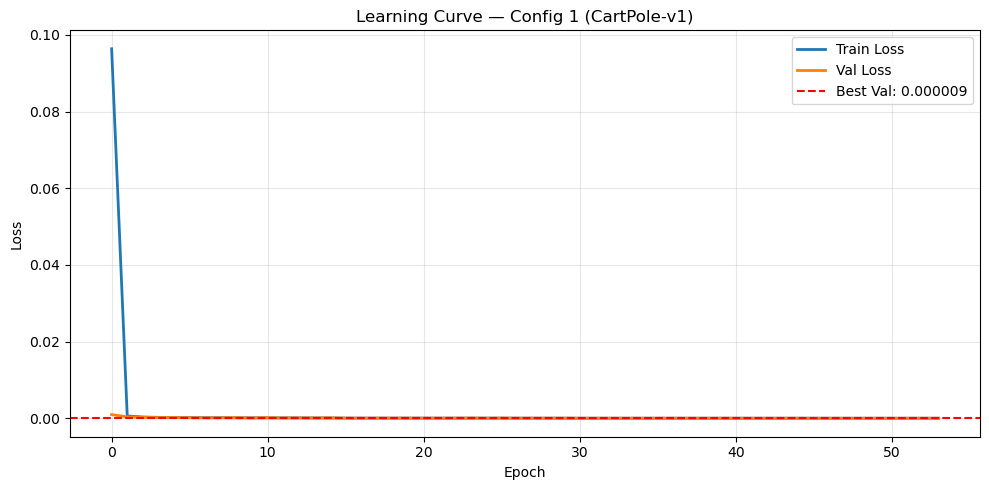

[PLOT] → world_model/plots/losses_config1.png


In [12]:
model_c1, best_val_c1, test_mse_c1, test_mae_c1 = train_world_model(
    config=1,
    X_tr=X_tr_c1, Y_tr=Y_tr_c1,
    X_va=X_va_c1, Y_va=Y_va_c1,
    X_te=X_te_c1, Y_te=Y_te_c1,
)

## 8. Entraîner Config 2 (MultiStep)


  WorldModel | env=CartPole-v1 | config=2
  device=cpu | hidden=64 | epochs=200

[WM] Paramètres : 9,540

  Epoch   1/200 | train=0.168647 | val=0.003029 | best_val=0.003029 | lr=1.0e-03
  Epoch   5/200 | train=0.000499 | val=0.000355 | best_val=0.000355 | lr=1.0e-03
  Epoch  10/200 | train=0.000177 | val=0.000147 | best_val=0.000147 | lr=1.0e-03
  Epoch  15/200 | train=0.000107 | val=0.000092 | best_val=0.000068 | lr=5.0e-04
  Epoch  20/200 | train=0.000036 | val=0.000047 | best_val=0.000036 | lr=5.0e-04
  Epoch  25/200 | train=0.000034 | val=0.000032 | best_val=0.000024 | lr=5.0e-04
  Epoch  30/200 | train=0.000035 | val=0.000016 | best_val=0.000016 | lr=2.5e-04
  Epoch  35/200 | train=0.000012 | val=0.000012 | best_val=0.000012 | lr=2.5e-04
  Epoch  40/200 | train=0.000015 | val=0.000012 | best_val=0.000011 | lr=2.5e-04
  Epoch  45/200 | train=0.000012 | val=0.000012 | best_val=0.000011 | lr=1.3e-04
  Epoch  50/200 | train=0.000008 | val=0.000006 | best_val=0.000006 | lr=1.3e-04
  

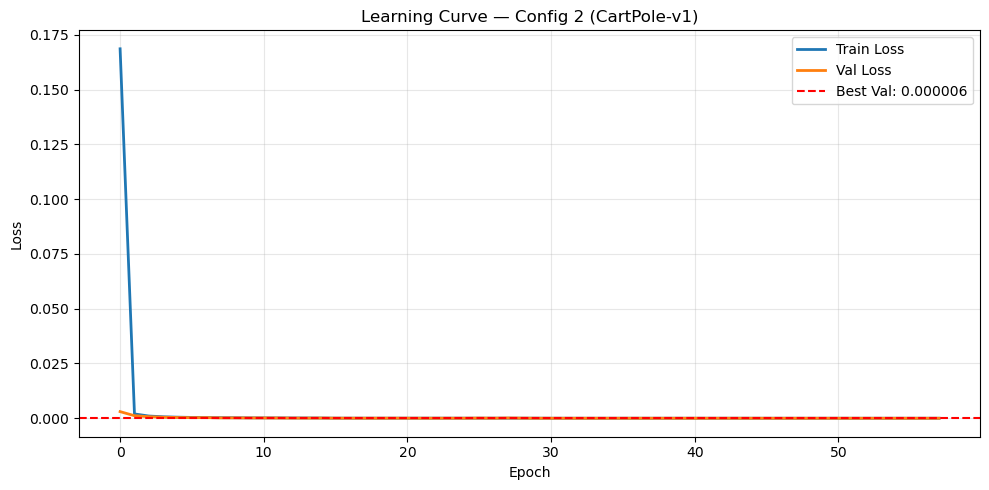

[PLOT] → world_model/plots/losses_config2.png


In [13]:
model_c2, best_val_c2, test_mse_c2, test_mae_c2 = train_world_model(
    config=2,
    X_tr=X_tr_c2, Y_tr=Y_tr_c2,
    X_va=X_va_c2, Y_va=Y_va_c2,
    X_te=X_te_c2, Y_te=Y_te_c2,
)

## 9. Entraîner Config 3 (Delta)


  WorldModel | env=CartPole-v1 | config=3
  device=cpu | hidden=64 | epochs=200

[WM] Paramètres : 9,028

  Epoch   1/200 | train=0.003632 | val=0.000034 | best_val=0.000034 | lr=1.0e-03
  Epoch   5/200 | train=0.000008 | val=0.000007 | best_val=0.000007 | lr=1.0e-03
  Epoch  10/200 | train=0.000004 | val=0.000003 | best_val=0.000003 | lr=1.0e-03
  Epoch  15/200 | train=0.000003 | val=0.000002 | best_val=0.000002 | lr=5.0e-04
  Epoch  20/200 | train=0.000001 | val=0.000001 | best_val=0.000001 | lr=5.0e-04

[WM] Early stopping à l'epoch 24 (best_val=0.000001)

[TEST] MSE=0.000002 | MAE=0.000780

[SAVE] → world_model/checkpoints_CartPole/wm_CartPole-v1_config3.pt


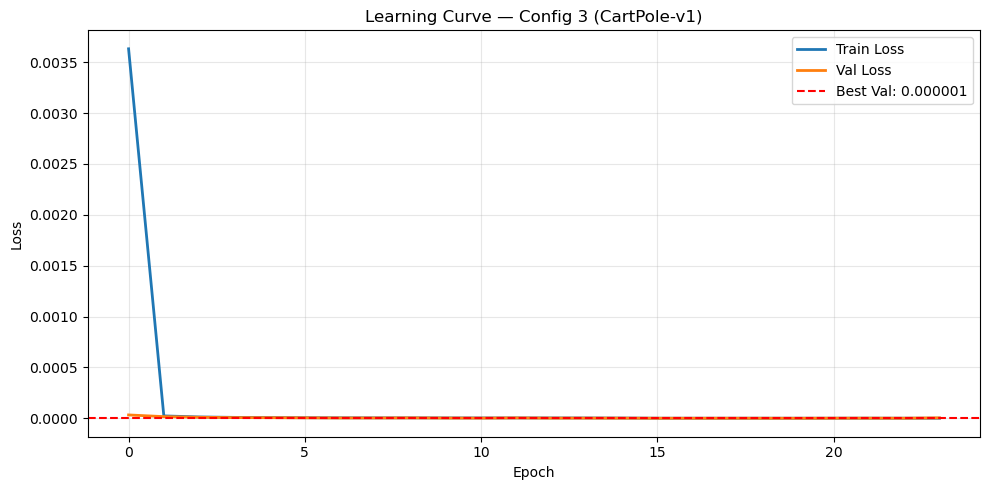

[PLOT] → world_model/plots/losses_config3.png


In [14]:
model_c3, best_val_c3, test_mse_c3, test_mae_c3 = train_world_model(
    config=3,
    X_tr=X_tr_c3, Y_tr=Y_tr_c3,
    X_va=X_va_c3, Y_va=Y_va_c3,
    X_te=X_te_c3, Y_te=Y_te_c3,
)

## 10. Résumé & Comparaison

In [ ]:
print(f"\n{'='*70}")
print(f"  RÉSUMÉ DES 3 CONFIGURATIONS — {ENV_NAME}")
print(f"{'='*70}\n")

results = [
    ("Config 1 (Standard)", best_val_c1, test_mse_c1, test_mae_c1),
    ("Config 2 (MultiStep n=5)", best_val_c2, test_mse_c2, test_mae_c2),
    ("Config 3 (Delta)", best_val_c3, test_mse_c3, test_mae_c3),
]

for name, best_val, test_mse, test_mae in results:
    print(f"{name}:")
    print(f"  Best Val Loss: {best_val:.6f}")
    print(f"  Test MSE:     {test_mse:.6f}")
    print(f"  Test MAE:     {test_mae:.6f}")
    print()


best_config = min(results, key=lambda x: x[1])
print(f"🏆 Meilleure config: {best_config[0]} (Val Loss: {best_config[1]:.6f})")
print(f"\n✅ Entraînement terminé! Checkpoints sauvegardés dans {CHECKPOINT_DIR}")


  RÉSUMÉ DES 3 CONFIGURATIONS — CartPole-v1

Config 1 (Standard):
  Best Val Loss: 0.000009
  Test MSE:     0.000011
  Test MAE:     0.002122

Config 2 (MultiStep n=5):
  Best Val Loss: 0.000006
  Test MSE:     0.000008
  Test MAE:     0.001597

Config 3 (Delta):
  Best Val Loss: 0.000001
  Test MSE:     0.000002
  Test MAE:     0.000780

🏆 Meilleure config: Config 3 (Delta) (Val Loss: 0.000001)

✅ Entraînement terminé! Checkpoints sauvegardés dans world_model/checkpoints_CartPole
